<a href="https://colab.research.google.com/github/glwat/Durham_Masters/blob/main/Missing_Data_Imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Codeblock K001: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#@title Codeblock K002: Load Master_Rockfall_2021.xlsx
import pandas as pd

file_path = "/content/drive/MyDrive/Masters_Colab_Data/Master_Rockfall_2021.xlsx"

df = pd.read_excel(file_path, index_col=False)

print("Loaded file:")
print(df.head())
print(f"\nRows loaded: {len(df)}")

Loaded file:
   ID            Datetime Gap_Rockfall  Gap_hours  Rockfall_Volume  \
0   2 2021-01-01 01:00:00        NoGap        NaN              0.0   
1   3 2021-01-01 02:00:00        NoGap        NaN              0.0   
2   4 2021-01-01 03:00:00        NoGap        NaN              0.0   
3   5 2021-01-01 04:00:00          NaN        NaN              NaN   
4   6 2021-01-01 05:00:00          NaN        NaN              NaN   

   Volume_Error  Rockfall_Event_Count  Total_Rainfall  Air_Temp  \
0           0.0                   0.0            0.00       4.1   
1           0.0                   0.0            0.51       5.5   
2           0.0                   0.0            0.51       5.8   
3           NaN                   NaN            0.51       5.8   
4           NaN                   NaN            1.27       5.2   

   Relative_Humidity  ...  Tmaxdiff W1-BSS-Tmean  W2-IBSS-Tmean  \
0               88.9  ...       NaN          NaN            NaN   
1               93.4  ...    

In [ ]:
#@title Codeblock K010a: Install pykalman
!pip install pykalman

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.1/252.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 13.5 MB/s eta 0:00:00


In [ ]:
#@title Codeblock K009: Clean Missing Values (Convert to NaN)

for col in df.columns:
    if df[col].dtype == object:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [ ]:
#@title Codeblock K010: Import Libraries
import numpy as np
import pandas as pd
from pykalman import KalmanFilter

In [ ]:
#@title Codeblock K011: Define Variables to Smooth

# Columns to exclude from smoothing
exclude_cols = [
    "Rockfall_Volume",
    "Rockfall_Event_Count",
    "ID",
    "Datetime",
    "Volume_Error",
    "Gap_hours",
    "Gap_Rockfall",
    "Total_Rainfall",
    "Rockfall_Occurrence",
    "Thermal_image_name",
    "Ref_File",
]

# Identify numeric columns eligible for smoothing
smooth_cols = [
    col for col in df.columns
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])
]

print("Variables selected for Kalman smoothing:")
print(smooth_cols)

Variables selected for Kalman smoothing:
['Air_Temp', 'Relative_Humidity', 'Hourly_Rainfall', 'TA', 'Tmean', 'Tmin', 'Tmax', 'Tmeandiff', 'Tmindiff', 'Tmaxdiff', 'W1-BSS-Tmean', 'W2-IBSS-Tmean', 'Ref_Mean', 'Ref_Max', 'Ref_Min', 'Ref_Range', 'Ref_sd', 'Gap_Rockfall_Kalman', 'Gap_Rockfall_Real', 'Air_Temp_Kalman', 'Air_Temp_Real', 'Relative_Humidity_Kalman', 'Relative_Humidity_Real', 'Hourly_Rainfall_Kalman', 'Hourly_Rainfall_Real', 'Thermal_image_name_Kalman', 'Thermal_image_name_Real', 'TA_Kalman', 'TA_Real', 'Tmean_Kalman', 'Tmean_Real', 'Tmin_Kalman', 'Tmin_Real', 'Tmax_Kalman', 'Tmax_Real', 'Tmeandiff_Kalman', 'Tmeandiff_Real', 'Tmindiff_Kalman', 'Tmindiff_Real', 'Tmaxdiff_Kalman', 'Tmaxdiff_Real', 'W1-BSS-Tmean_Kalman', 'W1-BSS-Tmean_Real', 'W2-IBSS-Tmean_Kalman', 'W2-IBSS-Tmean_Real', 'Ref_File_Kalman', 'Ref_File_Real', 'Ref_Mean_Kalman', 'Ref_Mean_Real', 'Ref_Max_Kalman', 'Ref_Max_Real', 'Ref_Min_Kalman', 'Ref_Min_Real', 'Ref_Range_Kalman', 'Ref_Range_Real', 'Ref_sd_Kalman', 'Re

In [ ]:
#@title Codeblock K012: Define Kalman Smoothing Function

def kalman_smooth_series(series, log_transform=False):
    """
    Applies Kalman smoothing to a 1D numeric series.
    Handles missing values automatically.
    Supports optional log-transform for non-negative variables.
    Returns smoothed series and mask (1 = observed, 0 = imputed).
    """

    x = series.astype(float).values

    # Mask: 1 = observed, 0 = missing
    mask = (~np.isnan(x)).astype(int)

    # Optional log-transform (for rainfall)
    if log_transform:
        x = np.log(x + 1)
        x[~np.isfinite(x)] = np.nan

    # Configure Kalman filter
    kf = KalmanFilter(
        transition_matrices=[1],
        observation_matrices=[1],
        initial_state_mean=np.nanmean(x),
        initial_state_covariance=1,
        observation_covariance=0.05,   # trust observations
        transition_covariance=0.2      # allow realistic variability
    )

    # Run smoothing
    smoothed, _ = kf.smooth(x)

    # Back-transform if needed
    if log_transform:
        smoothed = np.exp(smoothed) - 1
        smoothed = np.clip(smoothed, 0, None)

    return smoothed.flatten(), mask

In [ ]:
#@title Codeblock K013: Apply Kalman Smoothing to All Variables

for col in smooth_cols:

    # Special handling for rainfall (log-transform smoothing)
    if col.lower() == "hourly_rainfall":
        smoothed, mask = kalman_smooth_series(df[col], log_transform=True)

    else:
        smoothed, mask = kalman_smooth_series(df[col], log_transform=False)

        # Apply Relative Humidity constraints
        if col.lower() == "relative_humidity":
            smoothed = np.clip(smoothed, 0, 100)

    # Store results
    df[f"{col}_Kalman"] = smoothed
    df[f"{col}_Real"] = mask   # 1 = observed, 0 = imputed

print("Kalman smoothing applied to all variables with _Real mask indicators.")

/tmp/ipykernel_787/115244387.py:25: RuntimeWarning: Mean of empty slice
  initial_state_mean=np.nanmean(x),
/tmp/ipykernel_787/115244387.py:25: RuntimeWarning: Mean of empty slice
  initial_state_mean=np.nanmean(x),
/tmp/ipykernel_787/115244387.py:25: RuntimeWarning: Mean of empty slice
  initial_state_mean=np.nanmean(x),
/tmp/ipykernel_787/115244387.py:25: RuntimeWarning: Mean of empty slice
  initial_state_mean=np.nanmean(x),
/tmp/ipykernel_787/115244387.py:25: RuntimeWarning: Mean of empty slice
  initial_state_mean=np.nanmean(x),
/tmp/ipykernel_787/115244387.py:25: RuntimeWarning: Mean of empty slice
  initial_state_mean=np.nanmean(x),
/tmp/ipykernel_787/115244387.py:25: RuntimeWarning: Mean of empty slice
  initial_state_mean=np.nanmean(x),
/tmp/ipykernel_787/115244387.py:25: RuntimeWarning: Mean of empty slice
  initial_state_mean=np.nanmean(x),
/tmp/ipykernel_787/115244387.py:25: RuntimeWarning: Mean of empty slice
  initial_state_mean=np.nanmean(x),
/tmp/ipykernel_787/115244387

Kalman smoothing applied to all variables with _Real mask indicators.


/tmp/ipykernel_787/3035793040.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_Kalman"] = smoothed
/tmp/ipykernel_787/3035793040.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_Real"] = mask   # 1 = observed, 0 = imputed


In [ ]:
#@title Codeblock K014: Quick Diagnostic Summary

summary = pd.DataFrame({
    "Variable": smooth_cols,
    "Missing Before": [df[col].isna().sum() for col in smooth_cols],
    "Imputed Count": [df[f"{col}_Real"].eq(0).sum() for col in smooth_cols],
    "Observed Count": [df[f"{col}_Real"].eq(1).sum() for col in smooth_cols]
})

print(summary)

              Variable  Missing Before  Imputed Count  Observed Count
0         Gap_Rockfall            8376           8376               0
1             Air_Temp               0              0            8376
2    Relative_Humidity               0              0            8376
3      Hourly_Rainfall              46             46            8330
4   Thermal_image_name            8376           8376               0
5                   TA            4305           4305            4071
6                Tmean            4305           4305            4071
7                 Tmin            4305           4305            4071
8                 Tmax            4305           4305            4071
9            Tmeandiff            4305           4305            4071
10            Tmindiff            4305           4305            4071
11            Tmaxdiff            4305           4305            4071
12        W1-BSS-Tmean            4305           4305            4071
13       W2-IBSS-Tme

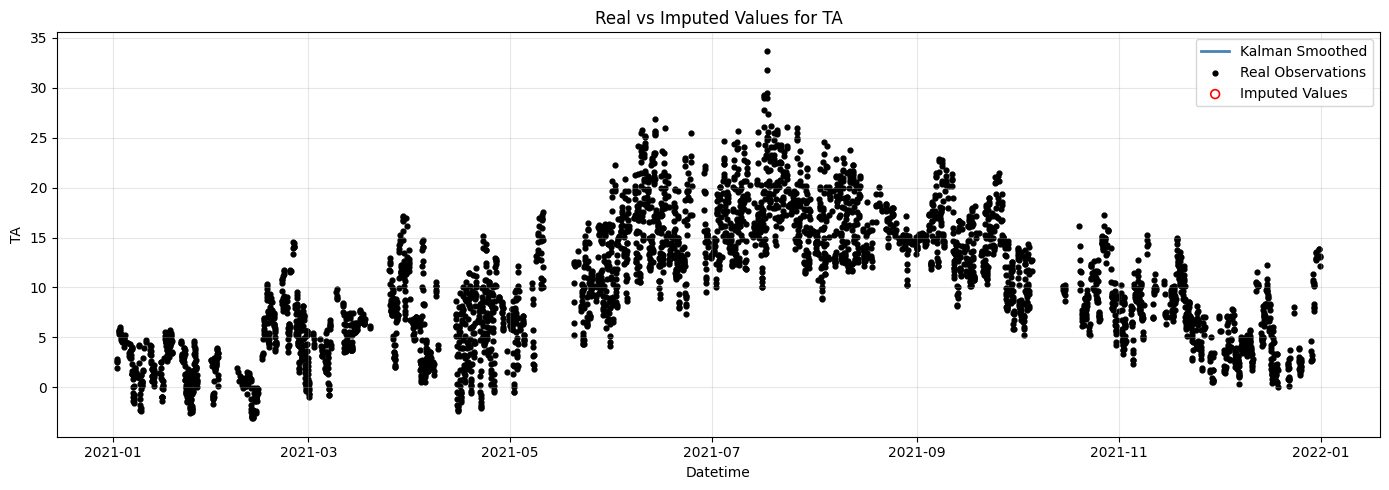

In [ ]:
#@title Codeblock K015: Plot Real vs Imputed for a Selected Variable
import matplotlib.pyplot as plt

# --- USER INPUT ---
variable = "TA"   # <-- change this to any variable you want to visualise
# -------------------

kalman_col = f"{variable}_Kalman"
real_col   = f"{variable}_Real"

if kalman_col not in df.columns or real_col not in df.columns:
    raise ValueError(f"Columns {kalman_col} and/or {real_col} not found. Check variable name.")

# Extract series
time = df["Datetime"]
raw = df[variable]
smooth = df[kalman_col]
real_mask = df[real_col]

plt.figure(figsize=(14, 5))

# Plot smoothed line
plt.plot(time, smooth, color="steelblue", linewidth=2, label="Kalman Smoothed")

# Plot real observations
plt.scatter(
    time[real_mask == 1],
    raw[real_mask == 1],
    color="black",
    s=12,
    label="Real Observations"
)

# Plot imputed points
plt.scatter(
    time[real_mask == 0],
    smooth[real_mask == 0],
    facecolors="none",
    edgecolors="red",
    s=40,
    linewidth=1.2,
    label="Imputed Values"
)

plt.title(f"Real vs Imputed Values for {variable}")
plt.xlabel("Datetime")
plt.ylabel(variable)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Check mask distribution for your chosen variable
variable = "TA"   # or whatever you plotted
print(df[f"{variable}_Real"].value_counts(dropna=False))

# Check how many NaNs were originally present
print("Original missing:", df[variable].isna().sum())

TA_Real
0    4305
1    4071
Name: count, dtype: int64
Original missing: 4305


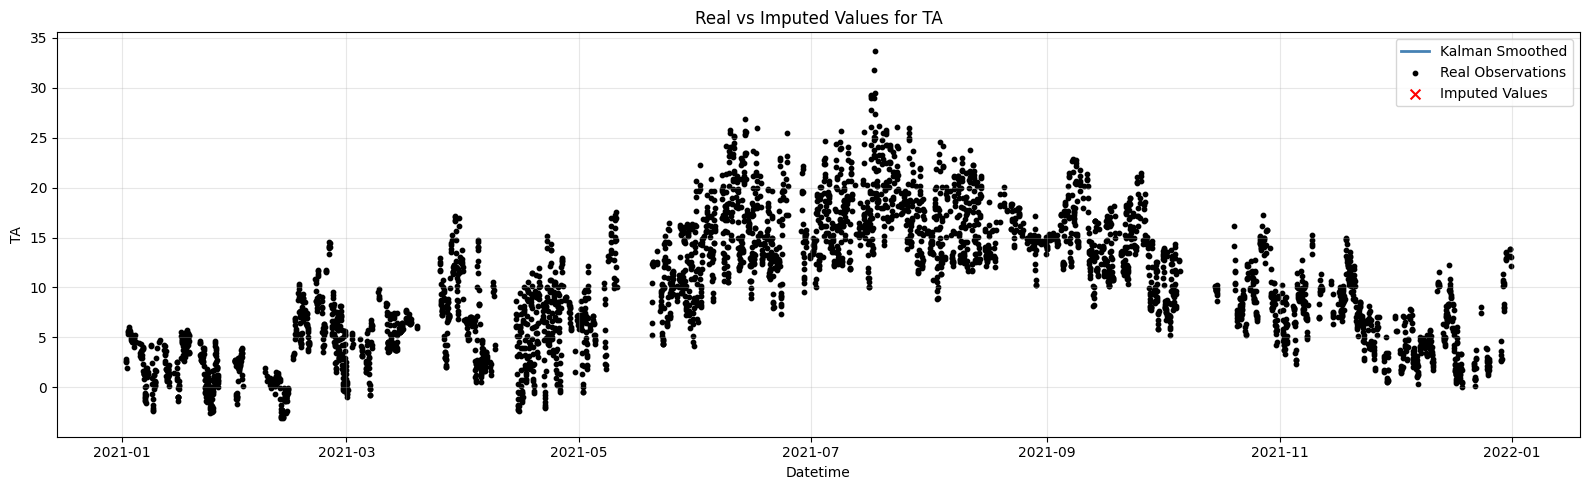

In [ ]:
#@title Codeblock K016: High-Visibility Imputation Plot

import matplotlib.pyplot as plt

variable = "TA"   # change as needed

kalman_col = f"{variable}_Kalman"
real_col   = f"{variable}_Real"

time = df["Datetime"]
raw = df[variable]
smooth = df[kalman_col]
real_mask = df[real_col]

plt.figure(figsize=(16, 5))

# Smoothed line
plt.plot(time, smooth, color="steelblue", linewidth=2, label="Kalman Smoothed")

# Real observations
plt.scatter(
    time[real_mask == 1],
    raw[real_mask == 1],
    color="black",
    s=10,
    label="Real Observations"
)

# Imputed observations (high visibility)
plt.scatter(
    time[real_mask == 0],
    smooth[real_mask == 0],
    color="red",
    marker="x",
    s=50,
    linewidth=1.5,
    label="Imputed Values"
)

plt.title(f"Real vs Imputed Values for {variable}")
plt.xlabel("Datetime")
plt.ylabel(variable)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8376 entries, 0 to 8375
Data columns (total 62 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ID                        8376 non-null   int64         
 1   Datetime                  8376 non-null   datetime64[ns]
 2   Gap_Rockfall              5193 non-null   object        
 3   Gap_hours                 258 non-null    float64       
 4   Rockfall_Volume           5193 non-null   float64       
 5   Volume_Error              5193 non-null   float64       
 6   Rockfall_Event_Count      5193 non-null   float64       
 7   Total_Rainfall            8376 non-null   float64       
 8   Air_Temp                  8376 non-null   float64       
 9   Relative_Humidity         8376 non-null   float64       
 10  Hourly_Rainfall           8330 non-null   float64       
 11  Thermal_image_name        4071 non-null   object        
 12  TA                  